#Loading Data

In [45]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df = pd.read_csv("/content/drive/MyDrive/Dataset/ML_AI/Iris.csv")
print ("Dataset Preview:")
print (df.head())

print ("\nDataset Information:")
print (df.info())

Dataset Preview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
mem

# Preparing Feature Matrix and Label Vector with Conversion to One Hot Encoding

In [46]:
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y_encoded.reshape(-1, 1))

print("\nUnique Classes:", np.unique(y))
print("\nEncoded Labels:", np.unique(y_encoded))
print("\nOne-Hot Encoded Labels:\n", y_one_hot[:5])



Unique Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Encoded Labels: [0 1 2]

One-Hot Encoded Labels:
 [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


# Train Test Split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y_one_hot, test_size=0.2, random_state=42, stratify=y_one_hot)
print("\nShapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Shapes:
X_train: (120, 4) y_train: (120, 3)
X_test: (30, 4) y_test: (30, 3)


# Implementing Softmax Function

In [48]:
import numpy as np
def softmax(z):
  z_shifted = z - np.max(z, axis=1, keepdims=True)
  exp_z = np.exp(z_shifted)
  return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Implementing Categorical Cross Entropy Loss Function

In [49]:
def loss_softmax(y_pred, y):
  epsilon = 1e-12
  y_pred = np.clip(y_pred, epsilon, 1. - epsilon)
  n = y.shape[0]
  loss = -np.sum(y * np.log(y_pred)) / n
  return loss

# Implementing Cost Function

In [50]:
def cost_softmax(X, y, W, b):
  n = X.shape[0]
  z = np.dot(X, W) + b
  y_pred = softmax(z)
  cost = loss_softmax(y_pred, y)
  return cost

# Comupting the Gradients

In [51]:
def compute_gradient_softmax(X, y, W, b):
    n, d = X.shape
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n
    return grad_W, grad_b

# A Gradient Descent Algorithm

In [56]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
  cost_history =[]
  for i in range(n_iter):
    grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
    W -= alpha * grad_W
    b -= alpha * grad_b
    cost = cost_softmax(X, y, W, b)
    cost_history.append(cost)
    if show_cost and (i % 100 == 0 or i == n_iter-1):
      print(f"Iteration {i}: Cost = {cost:.6f}")
  return W, b, cost_history

# Prediction Function to Assign a Class

In [57]:
def predict_softmax(X, W, b):
  z = np.dot(X,W) + b
  y_pred = softmax(z)

  predicted_classes = np.argmax(y_pred, axis=1)
  return predicted_classes

# Training the Model

Iteration 0: Cost = 1.010948
Iteration 100: Cost = 0.472310
Iteration 200: Cost = 0.265535
Iteration 300: Cost = 0.222618
Iteration 400: Cost = 0.195268
Iteration 500: Cost = 0.176136
Iteration 600: Cost = 0.161958
Iteration 700: Cost = 0.151004
Iteration 800: Cost = 0.142267
Iteration 900: Cost = 0.135123
Iteration 999: Cost = 0.129219


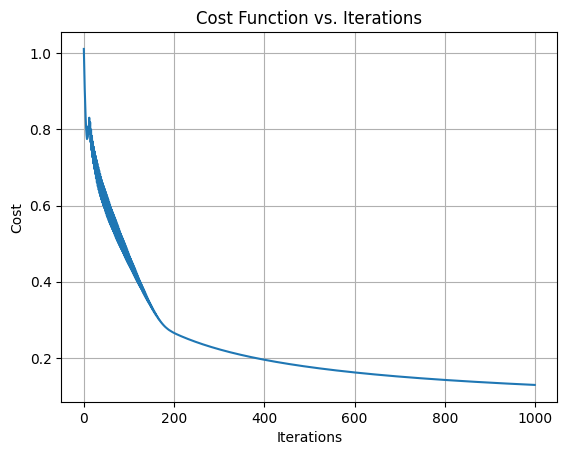

In [58]:
import matplotlib.pyplot as plt

# Initialize the weights and biases
d = X_train.shape[1]  # Number of features
c = y_train.shape[1]  # Number of classes
W = np.random.randn(d, c) * 0.01  # Small random weights
b = np.zeros(c)  # Bias initialized to 0

# Set hyperparameters
alpha = 0.1       # Learning rate
n_iter = 1000     # Number of iterations

# Train the model using gradient descent
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Plot the cost history to visualize convergence
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

# Testing ad Evaluation

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

# Final Evaluation

In [60]:
# Predict on the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Evaluate accuracy
y_test_labels = np.argmax(y_test, axis=1)  # True labels in numeric form

# Evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print the evaluation metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.97
Recall: 0.97
F1-Score: 0.97
